In [1]:
from pathlib import Path
import os
import sys
from dotenv import load_dotenv
load_dotenv()

project_root = Path.cwd().parent

os.chdir(project_root)

sys.path.insert(0, str(project_root / "src"))

import base64

import httpx

from langchain_core.messages import HumanMessage

from agent.graph import agent

2026-03-08 18:34:13.520804787 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


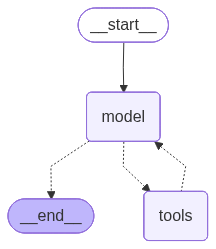

In [2]:
agent

In [3]:
image_url = "https://preview.redd.it/help-my-grape-vine-seems-to-be-sick-v0-g619rhhxz61b1.jpg?width=1080&crop=smart&auto=webp&s=9469c8202f5c7a4d55c8c7422cf61538bdc4bc67"

In [4]:
human = HumanMessage(
    content=[
        {
            "type": "text",
            "text": (
                "My Grape vine has an amazing out of grapes this year but I've noticed some leaves have this odd spotting on them and it's killing off some leaves entirely. Can you help me identify what's going on and how to treat??"
            ),
        },
        {
            "type": "image_url",
            "image_url": image_url,
        },
    ]
)

In [5]:
inputs = {
    "messages": [human],
    "current_image_url": image_url,
}

async for chunk in agent.astream(
    input=inputs,
    stream_mode="updates",
):
    for node_name, node_update in chunk.items():
        print(f"\nNode: {node_name}")
        print(f"Update: {node_update}")
        print("-" * 40)


Node: model
Update: {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'closed_set_leaf_detection', 'arguments': '{"confidence_threshold": 0.3}'}, '__gemini_function_call_thought_signatures__': {'10ead8c5-2869-4fdc-ad59-75e7a3eac414': 'EooJCocJAb4+9vtrPg+CPH1owNqJq0JGakeW2QZO6KT44uy9NtbpFgwT51JyT6TtGQVjyAL2Se+n9QPy16f7TLFbwSE4+GZok7NxWP5oWvbFjIJUH+DllbQP5KfFiZzfKILMq/zDgZDQnwmmt7esmSdTxAz3u5MJEZRngE1M0DYU+PFvACj0CxnqMkWS0urWKYNCBodEmNEshkJX8h3dwLrSKBwNDV3Uke/NeUji4vSRdgS0Qg+sBJFcn2xNlkuUC6d4xPp9IzF9SEcSkVm5b4LpEulbqOfnJmDTozx050Iryv8OA6G4R2GmoyjV/WsIy0eDcnCmMtlNnTcTPm2NYvbSJKPwBzb+kcG7UyXCPW8QWF14ySc4dAzwWaLU4U+Pjq+tpwAtlCFK71+oJ1Wxs3AMoiaP/kGvgUQy83geC3aflqyEUzddGdYi/DBSvBzDFGVSDV3dGiOaDOWhe4Tu6GXrDqFbdNFpXkwjN2srP0nQQ4lbcb+XrKc6bA929C5E/RYWG76eTPh7QEt1ForBsFMQzWvUGsKI5HIn7jRrEOk6lVCOud9lgUJajOBZB9XaR5XCoR/MYBmQ7o0YRHo5WAP9vQxCmpZe5gWHn7PPCsGDLuEs7p+bSRReS6LDwriiZhjIeI4wEJqmu+wt/psdJ/645ZV6DdfCUiBCEDi19RIoEbNhHpgGopIy9+PqkGB+NLQkZ+yn0CqWU+X+lEfadBt2Y9T4G

In [ ]:
from dotenv import load_dotenv
from langchain_tavily import TavilySearch

load_dotenv()

query = "organic treatment for grape black rot during fruit set"

search = TavilySearch(max_results=3)
web_docs = search.invoke(query)

print("=" * 60)
print("Hasil Pencarian Web via Tavily Search API")
print("=" * 60)
print(f"Query: {query}\n")

for i, doc in enumerate(web_docs["results"], 1):
    print(f"[{i}] {doc.get('title', 'Tanpa Judul')}")
    print(f"    URL    : {doc.get('url', '-')}")
    print(f"    Konten : {doc.get('content', '')[:100]}...")
    print(f"    Skor : {doc.get('score', '')}")
    print()


Hasil Pencarian Web via Tavily Search API
Query: organic treatment for grape black rot during fruit set

[1] Effective measures to kill black rot on grapevines organically
    URL    : https://www.facebook.com/groups/plant.health.pests.and.diseases/posts/3064519410520591/
    Konten : Copper sulfate is a decent organic fungicide. For black spot on my grapes it wasn't effective though...
    Skor : 0.680136

[2] Black ROT Be Gone ™ 60 ml All Organic Promotes Healing of Black ...
    URL    : https://www.blackknotbegone.com/products/black-rot-be-gone
    Konten : Black ROT Be Gone ™ 60 ml All  Organic Promotes Healing of Black Rot in Apple trees, Grapevines, and...
    Skor : 0.5798055

[3] Grapes 101: Managing Black Rot - Cornell CALS
    URL    : https://cals.cornell.edu/news/2014/03/grapes-101-managing-black-rot
    Konten : ### Managing Black Rot. Black rot  (Guignardia bidwellii (Ellis)) is a potentially devastating funga...
    Skor : 0.55275756



: 